In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Cleaning Data...
Removing NaN rows...
Removing inf rows...
Removing Bad Flags...
Removing Duplicates...

        Cleaning Report
        -------------------------
        Original Points : 4075
        Final Points    : 3688

        NaN Removed         : 5
        Inf Removed         : 0
        Bad Flags Removed   : 382
        Duplicates Removed  : 0
  

        Apply Filters :

        1. Apply MAD Filter

        2. Apply Detrending

        3. Apply Median Filter

        4. Apply Savitzky-Golay filter

        5. Apply all

        6. Exit


        
{'mad': np.float32(9.589844), 'threshold': 3, 'outliers_found': 32, 'outlier_indices': [72, 175, 176, 179, 230, 268, 364, 528, 533, 535, 536, 537, 538, 540, 547, 548, 549, 551, 557, 560, 565, 616, 1829, 2549, 2551, 2560, 2840, 2842, 3117, 3265, 3313, 3323]}


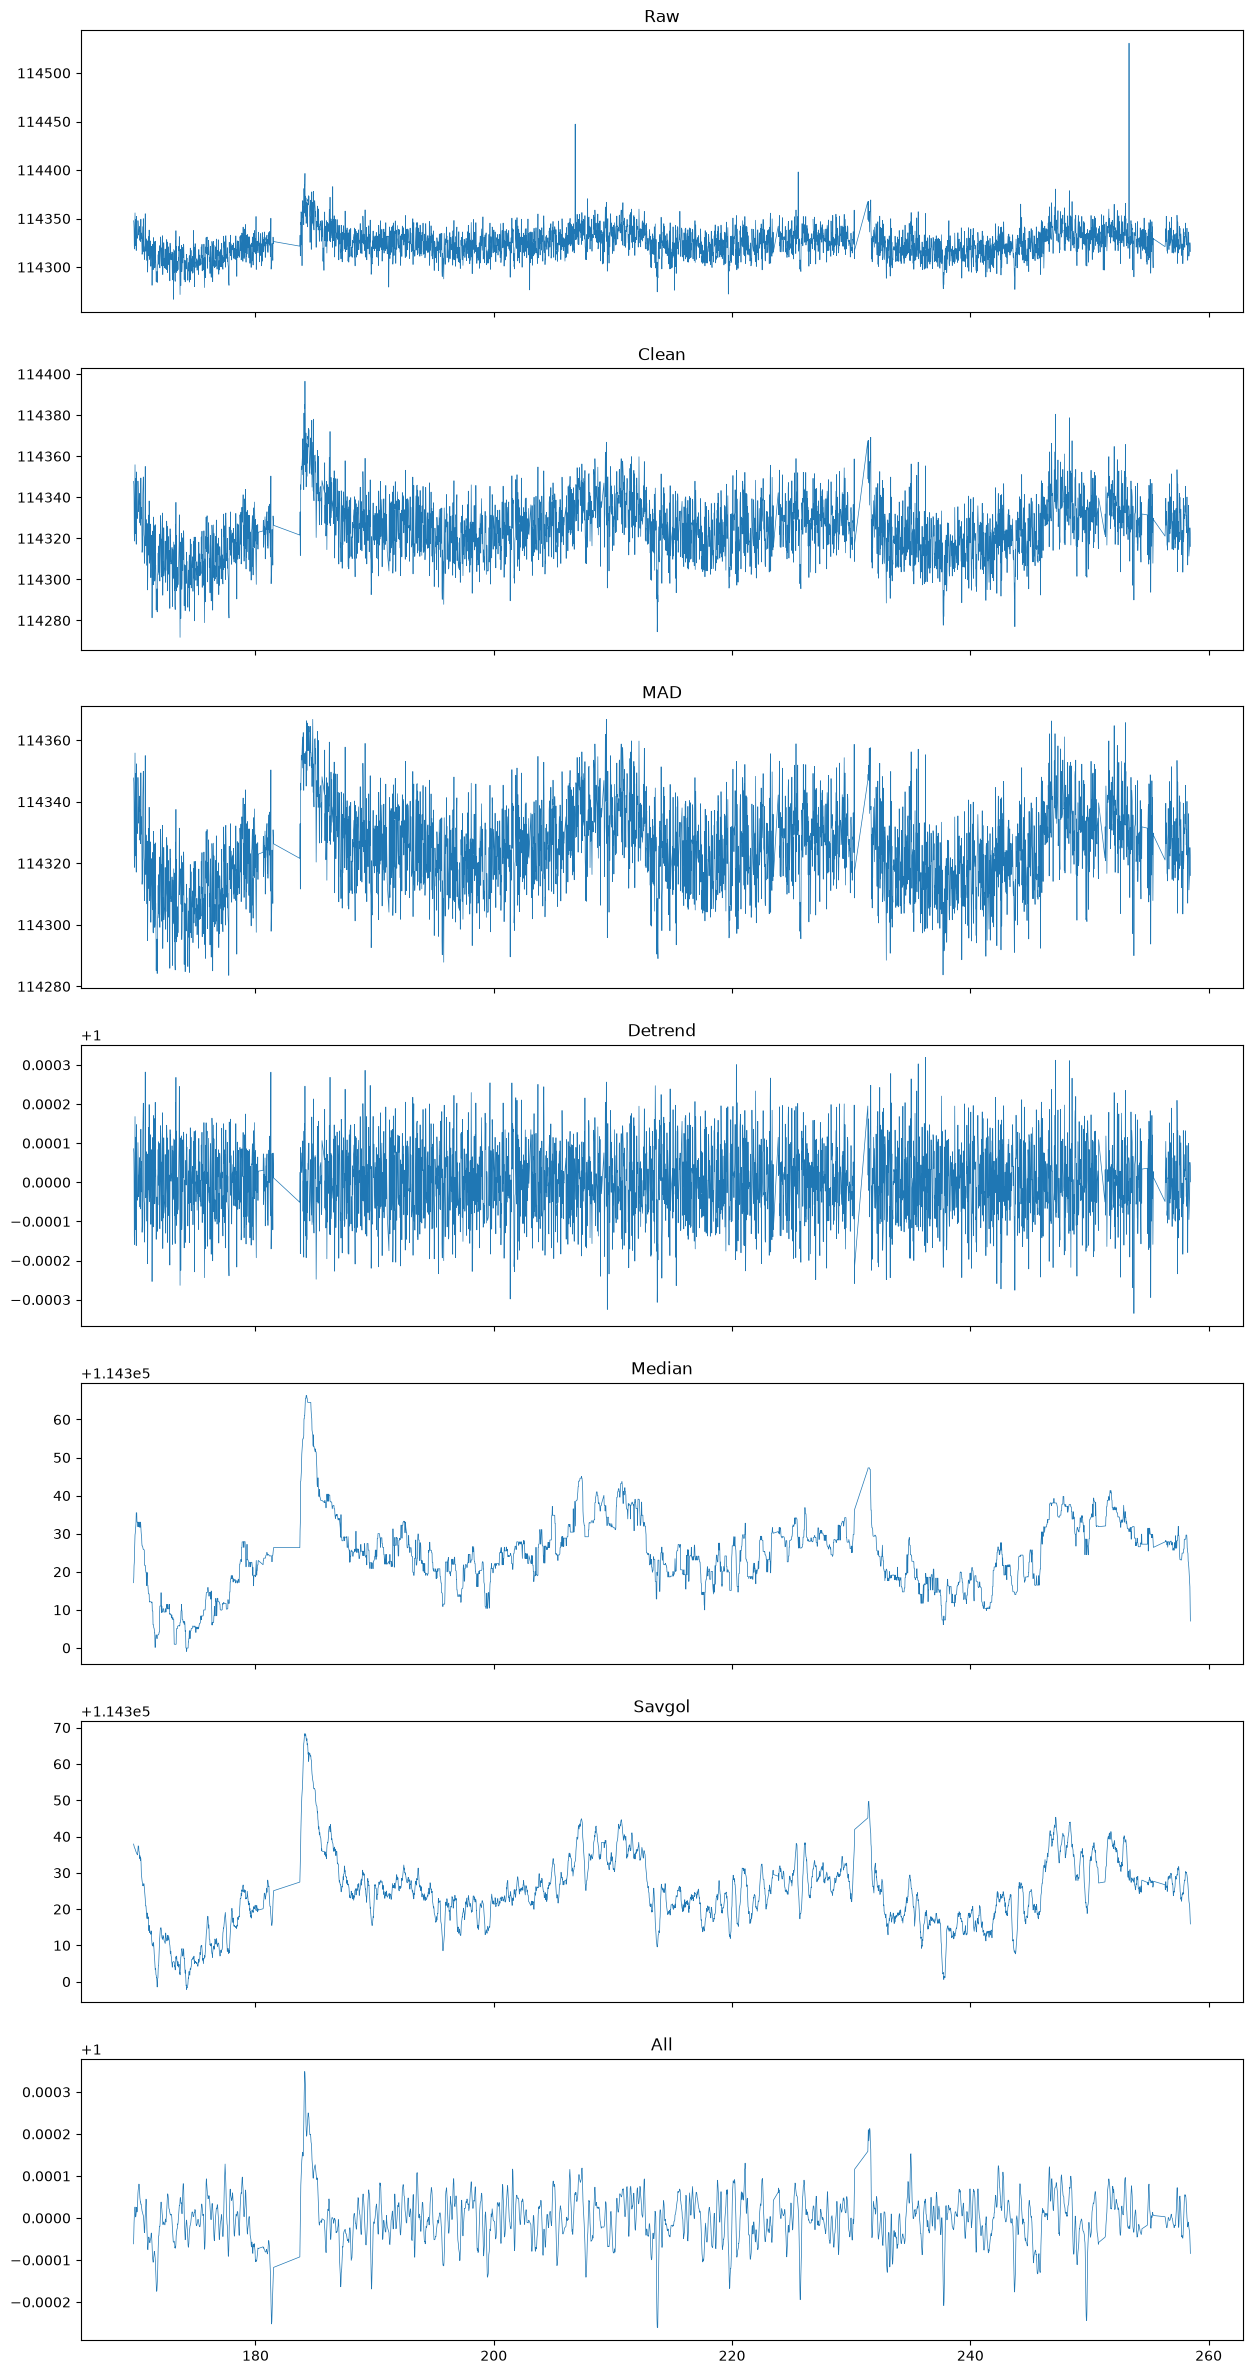

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
from preparing_data.cleaning_data import clean_data
from preparing_data.read_fits import read_fits
from filtering.mad_filter import mad_filter
from filtering.detrending import detrend_flux
from filtering.median_filter import median_filter
from filtering.savgol_filter import apply_savgol_filter
from filtering.filter_data import filter_data
from pathlib import Path
import matplotlib.pyplot as plt

raw = read_fits(Path("../data/raw/Kepler-135/Kepler-135_Kepler_Quarter_02.fits"))

clean , _ = clean_data(raw)

mad , mad_stat = mad_filter(clean, threshold=5)

detrend = detrend_flux(clean, window_length=31)

median = median_filter(clean, kernel_size=21)

savgol = apply_savgol_filter(clean, window_length=31)

all = filter_data(clean)

fig, ax = plt.subplots(7,1, figsize=(15,30), sharex=True)

ax[0].plot(raw.time, raw.flux, lw=0.5)
ax[0].set_title("Raw")

ax[1].plot(clean.time, clean.flux, lw=0.5)
ax[1].set_title("Clean")

ax[2].plot(mad.time, mad.flux, lw=0.5)
ax[2].set_title("MAD")

ax[3].plot(detrend.time, detrend.flux, lw=0.5)
ax[3].set_title("Detrend")

ax[4].plot(median.time, median.flux, lw=0.5)
ax[4].set_title("Median")

ax[5].plot(savgol.time, savgol.flux, lw=0.5)
ax[5].set_title("Savgol")

ax[6].plot(all.time, all.flux, lw=0.5)
ax[6].set_title("All")

print(mad_stat)